# Visualisering af studerendes eksamenspræstationer med 3D-overflader og scatterplots (PROC G3D)

## Resumé

Denne notebook bruger **PROC G3D** til at visualisere, hvordan to
undervisningsmæssige interventionsfaktorer tilsammen former studerendes
resultater i en uddannelsesanalytisk sammenhæng. Et komplet faktorielt
gitter driver en glat respons-**overflade** af forudsagte
eksamensresultater over ugentlige studietimer (0 til 20) og tidligere
karaktergennemsnit (0 til 4), og en syntetisk kohorte på 100 studerende
gengives som **3D-scatter**-paneler opdelt efter præstationsniveau.

Den tilpassede overflade stiger fra et forudsagt resultat på omkring 26
ved nul studietimer mod et loft på omkring 99 og flader ud, når
studietimerne passerer cirka 10 timer — den ryg af aftagende udbytte,
modellen indkoder. De studerendes paneler bekræfter mønstret på
individniveau: de 20 *Udmærkelse*-studerende (alle med 85 eller
derover) sidder i hjørnet med højt karaktergennemsnit og høj
studieindsats, mens de 33 studerende *i risiko* koncentrerer sig i
området med lav indsats og lavt karaktergennemsnit. En WHERE-filtreret
visning af det hjørne isolerer 35 studerende, for hvem beskedne
stigninger i studietid giver det største marginale udbytte.

## Datakilder

Alle data genereres direkte i koden med `call streaminit()` og
`rand()` — ingen eksterne filer eller netværksadgang.

**`score_grid`** — komplet faktorielt gitter, der driver
responsoverfladen (én række pr. celle af studietimer x tidligere
karaktergennemsnit, 99 rækker).

| Variabel | Type | Beskrivelse |
|----------|------|-------------|
| `study_hours` | Num | Ugentlige selvstudietimer, 0 til 20 i spring på 2 (X-akse) |
| `prior_gpa` | Num | Tidligere karaktergennemsnit på en skala fra 0-4, 0 til 4 i spring på 0.5 (Y-akse) |
| `pred_score` | Num | Modelleret afsluttende eksamensresultat 0-100 fra en mættende responsmodel (Z-akse) |

**`students`** — syntetisk individuel studenterkohorte til
scatterplottet (100 rækker).

| Variabel | Type | Beskrivelse |
|----------|------|-------------|
| `student_id` | Num | Fortløbende studenteridentifikator |
| `study_hours` | Num | Observerede ugentlige studietimer (X-akse) |
| `prior_gpa` | Num | Observeret tidligere karaktergennemsnit (Y-akse) |
| `exam_score` | Num | Observeret afsluttende eksamensresultat 0-100 (Z-akse) |
| `cohort` | Char | Indskrivningskohorte, `Efterår` eller `Forår` |
| `band` | Char | Præstationsniveau: `Udmærkelse` (≥85), `Bestået` (65-84), `I risiko` (<65) |

Gitteret er bevidst dimensioneret til 99 celler, så det dækker hele
intervallet 0-20 studietimer og 0-4 i karaktergennemsnit, samtidig med
at det holder sig inden for dette miljøs grænse på 100 observationer;
et 11 x 9-gitter holder overfladen glat uden at afkorte nogen af
akserne.

# Visualisering af studerendes eksamenspræstationer med PROC G3D

Uddannelsesforskere vil ofte forstå, hvordan to påvirkelige faktorer
tilsammen driver et resultat. Her spørger vi: *hvordan kombinerer
ugentlige studietimer og en studerendes tidligere karaktergennemsnit
sig for at forme den afsluttende eksamenspræstation?*

Et todimensionalt diagram kan ikke vise en interaktionsoverflade.
**PROC G3D** tegner ægte tredimensionale grafer ud fra variable i
`y*x=z`-notation, hvor X og Y udspænder det vandrette plan, og Z
stiger lodret. Vi bruger to af dets funktioner:

- **PLOT** — en kontinuert respons-*overflade* over et komplet gitter
  af de to prædiktorer.
- **SCATTER** — individuelle studerende plottet som 3D-symboler. Vi
  gengiver ét panel pr. præstationsniveau, hver med sin egen
  markørfarve og -form, så de tre resultatniveauer er lette at
  sammenligne.

Alt nedenfor kører på syntetiske data genereret direkte i koden, så
notebooken er fuldt selvstændig.

## Trin 1 — Generér gitteret til responsoverfladen

Et G3D-overfladeplot kræver et rimeligt komplet gitter: det kræver
ikke-manglende Z-værdier for mindst halvdelen af X-Y-cellerne. Vi
sikrer et *komplet* gitter ved at indlejre to `DO`-løkker over
`study_hours` (0 til 20 i spring på 2) og `prior_gpa` (0 til 4 i
spring på 0.5) — et 11 x 9-gitter med 99 celler, der dækker begge
akser fuldt ud.

Det forudsagte resultat følger en plausibel mættende model: udbyttet
af at studere aftager ved høje timetal, tidligere karaktergennemsnit
bidrager nogenlunde lineært, og de to interagerer (en stærk studerende
omsætter studietid til point mere effektivt). En lille reproducerbar
støj fra `rand('NORMAL')` forhindrer overfladen i at se perfekt
analytisk ud. `call streaminit()` fastsætter seedet, så gitteret er
reproducerbart.

In [1]:
data score_grid;
   CALL streaminit(20260531);
   GØR study_hours = 0 TIL 20 EFTER 2;     /* 11 værdier: hele 0-20-intervallet */
      GØR prior_gpa = 0 TIL 4 EFTER 0.5;   /* 9 værdier -> 99 gittercelller */
         /* mættende udbytte af studietid */
         effort = 40 * (1 - EXP(-study_hours / 6));
         /* tidligere præstation og et interaktionsled */
         base   = 8 * prior_gpa;
         inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
         pred_score = 25 + effort + base + inter
                      + rand('NORMAL') * 1.5;
         HVIS pred_score > 100 SÅ pred_score = 100;
         HVIS pred_score < 0   SÅ pred_score = 0;
         UDDATA;
      SLUT;
   SLUT;
   BEHOLD study_hours prior_gpa pred_score;
KØR;

PROCEDURE GENNEMSNIT data=score_grid n min mean max maxdec=1;
   VARIABEL study_hours prior_gpa pred_score;
KØR;

                                                  The MEANS Procedure

 Variable           N     Minimum        Mean     Maximum
 --------------------------------------------------------
 study_hours       99         0.0        10.0        20.0
 prior_gpa         99         0.0         2.0         4.0
 pred_score        99        25.7        70.0        98.7
 --------------------------------------------------------




NOTE: DATA score_grid


NOTE: Wrote score_grid (99 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Trin 2 — Tegn den grundlæggende responsoverflade

Med et komplet gitter i hånden tegner det simpleste kald overfladen
ved hjælp af procedurens standardindstillinger. Syntaksen `PLOT y*x=z`
kortlægger `prior_gpa` til Y-aksen, `study_hours` til X-aksen og det
forudsagte resultat til den lodrette Z-akse.

Vi mærker akserne med en `LABEL`-sætning og sætter titler og en
fodnote med de globale `TITLE`/`FOOTNOTE`-sætninger, så grafen
fremstår tydeligt.

                                        Overflade for forudsagt eksamensresultat                                        
                            Effekt af ugentlige studietimer og tidligere karaktergennemsnit                             

PROC G3D Output
Data: score_grid

Variables: Ugentlige studietimer, Tidligere karaktergennemsnit, Forudsagt eksamensresultat

Ugentlige studietimer  Tidligere karaktergennemsnit  Forudsagt eksamensresultat
---------------------  ----------------------------  --------------------------
                    0                             0               25.7031536911
                    0                           0.5               28.9516502743
                    0                             1               32.3400787822
                    0                           1.5               36.8265757618
                    0                             2               40.7806886968
                    0                           2.5                 42.


NOTE: GOPTIONS RESET=GLOBAL (unrecognized, treating as GOPTIONS).
NOTE: GOPTIONS BORDER enabled.
NOTE: Option TITLE changed to Overflade for forudsagt eksamensresultat.
NOTE: Option TITLE2 changed to Effekt af ugentlige studietimer og tidligere karaktergennemsnit.
NOTE: Option FOOTNOTE changed to Syntetiske uddannelsesanalysedata .
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: g3d_surface.spec.json


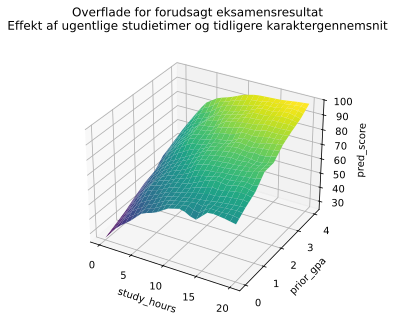

In [2]:
GOPTIONS reset=global border;

TITEL 'Overflade for forudsagt eksamensresultat';
title2 'Effekt af ugentlige studietimer og tidligere karaktergennemsnit';
footnote j=r 'Syntetiske uddannelsesanalysedata ';

PROCEDURE g3d data=score_grid;
   PLOT prior_gpa*study_hours=pred_score;
   MÆRKAT study_hours = 'Ugentlige studietimer'
         prior_gpa   = 'Tidligere karaktergennemsnit'
         pred_score  = 'Forudsagt eksamensresultat';
KØR;
QUIT;

## Trin 3 — Forfin overfladen med visnings- og akseindstillinger

Nogle få indstillinger gør overfladen langt mere læsbar:

- **ROTATE=** og **TILT=** sætter synsvinklen (grader omkring
  Z-aksen, og hældning mod betragteren).
- **XYTYPE=2** tegner overfladelinjer parallelt med Y-aksen, hvilket
  fremhæver, hvordan resultatet stiger med studietimer.
- **SIDE** tilføjer en sidevæg for et solidt, skulpturelt udseende.
- **GRID** tilføjer referencelinjer ved de vigtigste inddelinger.
- **ZMIN=/ZMAX=** og **ZTICKNUM=**-familien fastsætter
  resultataksen til hele intervallet 0-100, så overfladen ikke
  visuelt overdrives, mens **XTICKNUM=/YTICKNUM=** styrer
  gulvplanets inddelinger.
- **NAME=** og **DESCRIPTION=** mærker grafen i outputkataloget.

                             Overflade for forudsagt eksamensresultat (stiliseret visning)                              
                                            Roteret, vippet og akseskaleret                                             

PROC G3D Output
Data: score_grid

Variables: Ugentlige studietimer, Tidligere karaktergennemsnit, Forudsagt eksamensresultat

Ugentlige studietimer  Tidligere karaktergennemsnit  Forudsagt eksamensresultat
---------------------  ----------------------------  --------------------------
                    0                             0               25.7031536911
                    0                           0.5               28.9516502743
                    0                             1               32.3400787822
                    0                           1.5               36.8265757618
                    0                             2               40.7806886968
                    0                           2.5                 42.


NOTE: Option TITLE changed to Overflade for forudsagt eksamensresultat (stiliseret visning).
NOTE: Option TITLE2 changed to Roteret, vippet og akseskaleret.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: scoresurf.spec.json


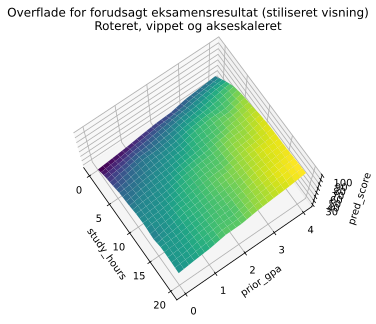

In [3]:
TITEL 'Overflade for forudsagt eksamensresultat (stiliseret visning)';
title2 'Roteret, vippet og akseskaleret';

PROCEDURE g3d data=score_grid;
   PLOT prior_gpa*study_hours=pred_score /
        rotate=55
        tilt=75
        xytype=2
        side
        grid
        zmin=0 zmax=100
        xticknum=5 yticknum=5 zticknum=6
        name="scoresurf"
        description="Stiliseret responsoverflade for eksamensresultat";
   MÆRKAT study_hours = 'Ugentlige studietimer'
         prior_gpa   = 'Tidligere karaktergennemsnit'
         pred_score  = 'Forudsagt eksamensresultat';
KØR;
QUIT;

## Trin 4 — Sammenlign overfladen fra flere synsvinkler

Fordi en 3D-overflade kan skjule struktur bag sine egne toppe, hjælper
det at gengive den samme overflade fra mere end én rotation. Her
udsteder vi tre PROC G3D-trin, der deler en fast hældning, men
trinvist ændrer **ROTATE=**-vinklen gennem 30, 90 og 150 grader, så
ryggen kan inspiceres forfra, fra siden og bagfra.

                                                    Responsoverflade                                                    
                                             ROTATE = 30 ved fast hældning                                              

PROC G3D Output
Data: score_grid

Variables: Ugentlige studietimer, Tidligere karaktergennemsnit, Forudsagt eksamensresultat

Ugentlige studietimer  Tidligere karaktergennemsnit  Forudsagt eksamensresultat
---------------------  ----------------------------  --------------------------
                    0                             0               25.7031536911
                    0                           0.5               28.9516502743
                    0                             1               32.3400787822
                    0                           1.5               36.8265757618
                    0                             2               40.7806886968
                    0                           2.5                 42.


NOTE: Option TITLE changed to Responsoverflade.
NOTE: Option TITLE2 changed to ROTATE = 30 ved fast hældning.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot30.spec.json
NOTE: Option TITLE changed to Responsoverflade.
NOTE: Option TITLE2 changed to ROTATE = 90 ved fast hældning.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot90.spec.json
NOTE: Option TITLE changed to Responsoverflade.
NOTE: Option TITLE2 changed to ROTATE = 150 ved fast hældning.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot150.spec.json


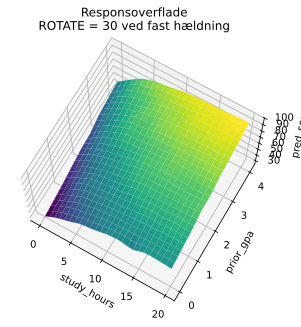

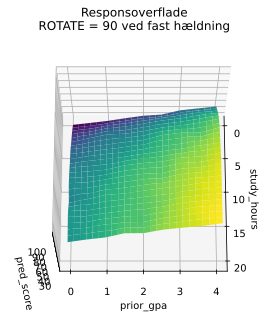

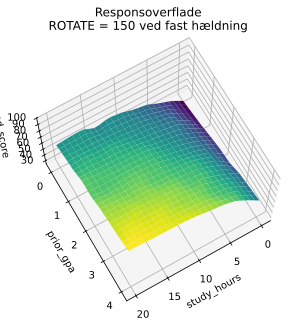

In [4]:
%macro angle(deg);
   TITEL 'Responsoverflade';
   title2 "ROTATE = &deg ved fast hældning";
   PROCEDURE g3d data=score_grid;
      PLOT prior_gpa*study_hours=pred_score /
           rotate=&deg
           tilt=70
           xytype=3
           zmin=0 zmax=100
           name="surf_rot&deg";
      MÆRKAT study_hours = 'Ugentlige studietimer'
            prior_gpa   = 'Tidligere karaktergennemsnit'
            pred_score  = 'Forudsagt eksamensresultat';
   KØR;
   QUIT;
%mend;

%angle(30);
%angle(90);
%angle(150);

## Trin 5 — Generér en syntetisk studenterkohorte

Overfladen er en model; virkelige studerende spreder sig omkring den.
Vi simulerer nu 100 individuelle studerende trukket fra to
indskrivningskohorter (`Efterår`, `Forår`). Hver studerende har
observerede studietimer, et tidligere karaktergennemsnit og et
støjet, realiseret eksamensresultat genereret fra den samme
responslogik plus større individuel variation.

Vi udleder derefter et præstations-**niveau** fra eksamensresultatet:
`Udmærkelse` (85 eller derover), `Bestået` (65 til 84) og `I risiko`
(under 65). PROC FREQ-krydstabuleringen nedenfor rapporterer, hvordan
niveauerne fordeler sig på tværs af de to kohorter. `rand('UNIFORM')`
og `rand('NORMAL')` leverer tilfældigheden; seedet holder det
reproducerbart.

                                                    Responsoverflade                                                    
                                             ROTATE = 150 ved fast hældning                                             

                                                   The FREQ Procedure

                                   Cumulative
Præstationsniveau     Frequency    Frequency
------------------------------------------------
Bestået                      47           47
I risiko                     33           80
Udmærkelse                   20          100

Table of Kohorte by Præstationsniveau

Kohorte  |    Bestået |   I risiko | Udmærkelse |       Total
---------+------------+------------+------------+------------
Efterår  |         20 |         15 |          6 |          41
---------+------------+------------+------------+------------
Forår    |         27 |         18 |         14 |          59
---------+------------+------------+------------+------------


NOTE: DATA students


NOTE: Wrote students (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_band.spec.json
NOTE: ODS plot written: freq_mosaic_cohort_band.spec.json
NOTE: PROC FREQ statement used.


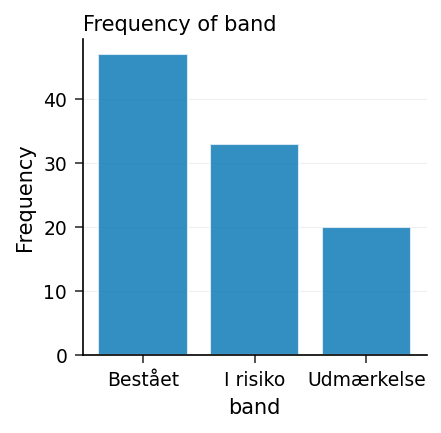

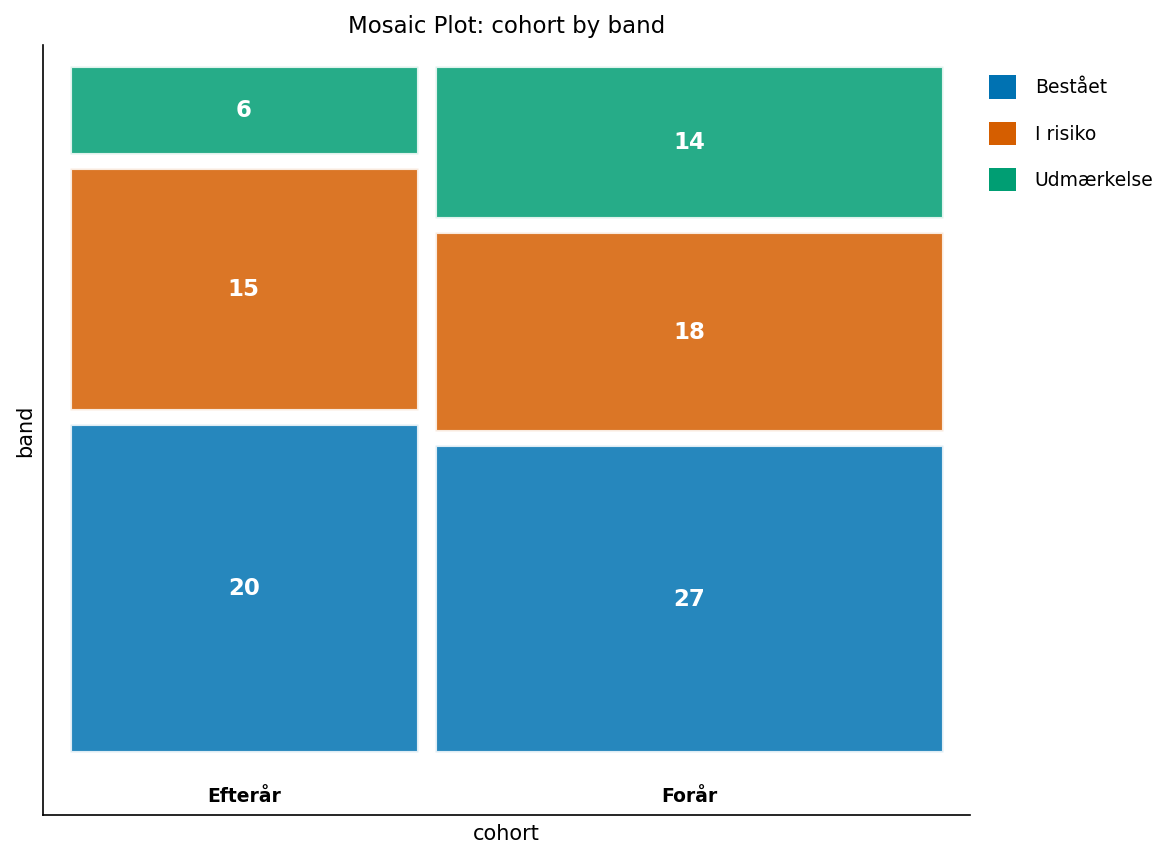

In [5]:
data students;
   CALL streaminit(99001);
   LÆNGDE cohort $10 band $12;
   GØR student_id = 1 TIL 100;
      HVIS rand('UNIFORM') < 0.5 SÅ cohort = 'Efterår';
      ELLERS cohort = 'Forår';

      study_hours = 20 * rand('UNIFORM');
      prior_gpa   = 4  * rand('UNIFORM');

      effort = 40 * (1 - EXP(-study_hours / 6));
      base   = 8 * prior_gpa;
      inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
      exam_score = 25 + effort + base + inter
                   + rand('NORMAL') * 7;
      HVIS exam_score > 100 SÅ exam_score = 100;
      HVIS exam_score < 0   SÅ exam_score = 0;

      HVIS exam_score >= 85 SÅ band = 'Udmærkelse';
      ELLERS HVIS exam_score >= 65 SÅ band = 'Bestået';
      ELLERS band = 'I risiko';

      UDDATA;
   SLUT;
   BEHOLD student_id cohort study_hours prior_gpa exam_score band;
KØR;

PROCEDURE FREKVENSER data=students;
   TABLES band cohort*band / nocol nopercent;
   MÆRKAT cohort = "Kohorte"
          band   = "Præstationsniveau";
KØR;

## Trin 6 — Plot studerende som 3D-scatterpaneler efter præstationsniveau

**SCATTER**-sætningen placerer hver studerende som et 3D-symbol. For
at gøre de tre præstationsniveauer lette at aflæse tegner vi ét panel
pr. niveau, hver filtreret med **WHERE** og givet sin egen
bogstavelige **COLOR=** og **SHAPE=**: grønne diamanter
(`SHAPE=diamond`) for *Udmærkelse*, blå markører (`SHAPE=club`) for
*Bestået* og røde markører (`SHAPE=spade`) for *I risiko*. **SIZE=**
forstørrer markørerne, **GRID** tilføjer gulvreferencelinjer,
**NONEEDLE** fjerner de lodrette faldlinjer, og **ZMIN=/ZMAX=** holder
hvert panel på den samme 0-100-resultatakse, så de tre visninger er
direkte sammenlignelige.

Hvert niveau får sit eget PROC G3D-trin, så dets WHERE-filter
anvendes rent, og markørstilen er utvetydig.

                                                 Udmærkelse-studerende                                                  
                                             Eksamensresultat 85 og derover                                             

PROC G3D Output
Data: students

Variables: student_id, cohort, Ugentlige studietimer, Tidligere karaktergennemsnit, Afsluttende eksamensresultat, band

student_id      cohort  Ugentlige studietimer  Tidligere karaktergennemsnit  Afsluttende eksamensresultat        band
----------  ----------  ---------------------  ----------------------------  ----------------------------  ----------
         2       Forår          19.2134883194                  2.6467742616                 90.3663886999  Udmærkelse
         5       Forår          15.5520919174                  2.7102003827                 94.9419468332  Udmærkelse
        10       Forår          14.2302640951                  3.8791496428                           100  Udmærkelse
        17     


NOTE: Option FOOTNOTE changed to Fra en kohorte på 100 syntetiske studerende .
NOTE: Option TITLE changed to Udmærkelse-studerende.
NOTE: Option TITLE2 changed to Eksamensresultat 85 og derover.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_honors.spec.json
NOTE: Option TITLE changed to Bestået-studerende.
NOTE: Option TITLE2 changed to Eksamensresultat 65 til 84.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_pass.spec.json
NOTE: Option TITLE changed to Studerende i risiko.
NOTE: Option TITLE2 changed to Eksamensresultat under 65.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_atrisk.spec.json


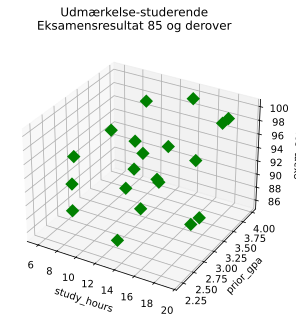

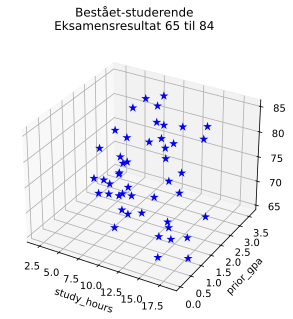

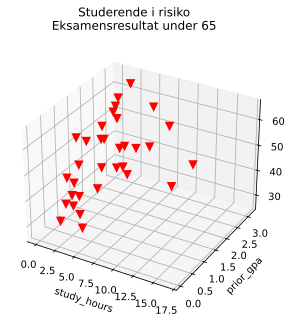

In [6]:
footnote j=r 'Fra en kohorte på 100 syntetiske studerende ';

/* Udmærkelse (exam_score >= 85): grønne diamanter */
TITEL 'Udmærkelse-studerende';
title2 'Eksamensresultat 85 og derover';
PROCEDURE g3d data=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=green shape=diamond size=3
           noneedle grid zmin=0 zmax=100
           name="band_honors"
           description="Udmærkelse-studerende";
   HVOR band = 'Udmærkelse';
   MÆRKAT study_hours = 'Ugentlige studietimer'
         prior_gpa   = 'Tidligere karaktergennemsnit'
         exam_score  = 'Afsluttende eksamensresultat';
KØR;
QUIT;

/* Bestået (65 <= exam_score < 85): blå klør */
TITEL 'Bestået-studerende';
title2 'Eksamensresultat 65 til 84';
PROCEDURE g3d data=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=blue shape=club size=3
           noneedle grid zmin=0 zmax=100
           name="band_pass"
           description="Bestået-studerende";
   HVOR band = 'Bestået';
   MÆRKAT study_hours = 'Ugentlige studietimer'
         prior_gpa   = 'Tidligere karaktergennemsnit'
         exam_score  = 'Afsluttende eksamensresultat';
KØR;
QUIT;

/* I risiko (exam_score < 65): røde spar */
TITEL 'Studerende i risiko';
title2 'Eksamensresultat under 65';
PROCEDURE g3d data=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red shape=spade size=3
           noneedle grid zmin=0 zmax=100
           name="band_atrisk"
           description="Studerende i risiko";
   HVOR band = 'I risiko';
   MÆRKAT study_hours = 'Ugentlige studietimer'
         prior_gpa   = 'Tidligere karaktergennemsnit'
         exam_score  = 'Afsluttende eksamensresultat';
KØR;
QUIT;

## Trin 7 — Separate scatterplots pr. indskrivningskohorte (BY-gruppe)

Programledere har ofte brug for den samme visning opdelt efter
kohorte. **BY**-sætningen producerer ét scatterplot pr. kohorte. G3D
forventer, at BY-gruppedata er sorteret, så vi sorterer først med
PROC SORT. Hver kohorte får derefter sit eget mærkede 3D-scatterplot
på en fælles 0-100-resultatakse, hvilket gør efterårs- og
forårsfordelingerne lette at sammenligne side om side.

                                     Eksamensresultater efter indskrivningskohorte                                      
                                     Ét 3D-scatterplot pr. kohorte (Efterår, Forår)                                     

PROC G3D Output
Data: students_sorted

Variables: student_id, cohort, Ugentlige studietimer, Tidligere karaktergennemsnit, Afsluttende eksamensresultat, band

student_id      cohort  Ugentlige studietimer  Tidligere karaktergennemsnit  Afsluttende eksamensresultat        band
----------  ----------  ---------------------  ----------------------------  ----------------------------  ----------
        52     Efterår          15.2586640362                  0.4602308374                 55.5186804916    I risiko
        13     Efterår           5.8493366471                  1.8449001873                 70.6084324429     Bestået
        15     Efterår           5.5070892672                  1.4478111608                 70.0069314398     Bestået
        


NOTE: PROC SORT data=students

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from students.
NOTE: Wrote students_sorted (100 rows, 6 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Eksamensresultater efter indskrivningskohorte.
NOTE: Option TITLE2 changed to Ét 3D-scatterplot pr. kohorte (Efterår, Forår).
NOTE: Option FOOTNOTE changed to Ét panel pr. kohorte .
NOTE: PROC G3D data=students_sorted

NOTE: ODS plot written: cohort_scatter_by1.spec.json
NOTE: ODS plot written: cohort_scatter_by2.spec.json


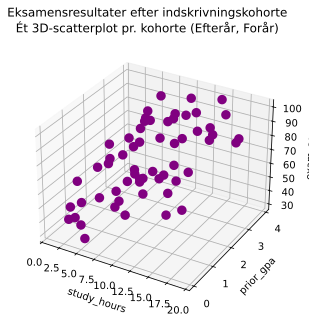

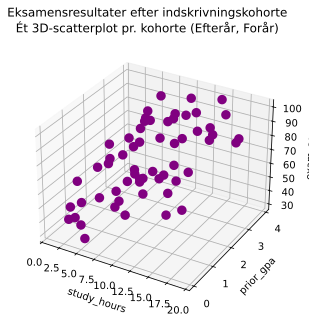

In [7]:
PROCEDURE SORTER data=students out=students_sorted;
   EFTER cohort;
KØR;

TITEL 'Eksamensresultater efter indskrivningskohorte';
title2 'Ét 3D-scatterplot pr. kohorte (Efterår, Forår)';
footnote j=r 'Ét panel pr. kohorte ';

PROCEDURE g3d data=students_sorted;
   EFTER cohort;
   SCATTER prior_gpa*study_hours=exam_score /
           color=purple
           shape=balloon
           size=3
           grid
           zmin=0 zmax=100
           name="cohort_scatter";
   MÆRKAT study_hours = 'Ugentlige studietimer'
         prior_gpa   = 'Tidligere karaktergennemsnit'
         exam_score  = 'Afsluttende eksamensresultat';
KØR;
QUIT;

## Trin 8 — Fokusér på risikogruppen med WHERE

Til intervensionsplanlægning er den mest handlingsorienterede visning
overfladens nederste venstre hjørne: studerende med både beskeden
studietid (8 timer eller derunder) og lavere tidligere
karaktergennemsnit (2.5 eller derunder). **WHERE**-sætningen
underopdeler scatterplottet til dette område, før det plottes.
Oversigten viser, at dette hjørne rummer 35 af de 100 studerende — 22
af dem allerede *i risiko* — så vejledere kan se præcis, hvilke
udfordrede studerende der sidder længst under forventning.

                     Interventionsfokus: studerende med lavere indsats og lavere karaktergennemsnit                     
                                         study_hours <= 8 and prior_gpa <= 2.5                                          

PROC G3D Output
Data: students

Variables: student_id, cohort, Ugentlige studietimer, Tidligere karaktergennemsnit, Afsluttende eksamensresultat, band

student_id      cohort  Ugentlige studietimer  Tidligere karaktergennemsnit  Afsluttende eksamensresultat        band
----------  ----------  ---------------------  ----------------------------  ----------------------------  ----------
         1     Efterår           4.9780700766                   1.072086769                  59.409228777    I risiko
         7       Forår           7.9015823058                  1.6623636789                 66.9055021729     Bestået
         9       Forår           2.5008494545                  0.3621033759                 48.1183184446    I risiko
        11     


NOTE: Option TITLE changed to Interventionsfokus: studerende med lavere indsats og lavere karaktergennemsnit.
NOTE: Option TITLE2 changed to study_hours <= 8 and prior_gpa <= 2.5.
NOTE: Option FOOTNOTE changed to Nålelinjer sænker hver markør til gulvplanet for study_hours x prior_gpa .
NOTE: PROC G3D data=students

NOTE: ODS plot written: g3d_scatter.spec.json


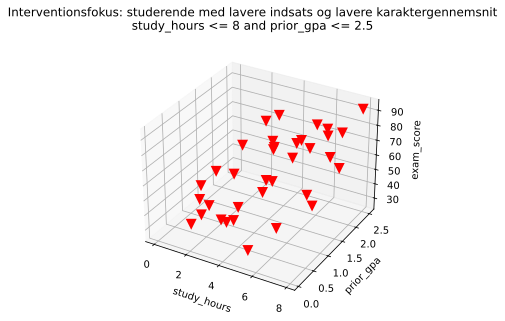

In [8]:
TITEL 'Interventionsfokus: studerende med lavere indsats og lavere karaktergennemsnit';
title2 'study_hours <= 8 and prior_gpa <= 2.5';
footnote j=r 'Nålelinjer sænker hver markør til gulvplanet for study_hours x prior_gpa ';

PROCEDURE g3d data=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red
           shape=spade
           size=4
           grid
           zmin=0 zmax=100;
   HVOR study_hours <= 8 AND prior_gpa <= 2.5;
   MÆRKAT study_hours = 'Ugentlige studietimer'
         prior_gpa   = 'Tidligere karaktergennemsnit'
         exam_score  = 'Afsluttende eksamensresultat';
KØR;
QUIT;

## Fortolkning af resultaterne

**Responsoverfladen** (trin 2-4) viser en klar mættende ryg. På tværs
af det 99-cellede gitter løber det forudsagte resultat fra omkring 26
(nul studietimer, nul karaktergennemsnit) op til omkring 99 (hjørnet
med høje studietimer og højt karaktergennemsnit), med et
gittergennemsnit nær 70. Læses langs studietimeaksen, stiger
resultaterne brat fra 0 mod omkring 10 timer og flader derefter ud,
efterhånden som yderligere timer giver aftagende udbytte; læses langs
karaktergennemsnitsaksen, løfter tidligere præstation hele overfladen
opad. Interaktionsleddet gør studietids-udbyttet en smule stejlere
for stærkere studerende, hvilket er grunden til, at overfladen vipper
mod sit fjerne hjørne snarere end at stige som et fladt plan.

**De studerendes paneler** (trin 6-7) bekræfter, at modellen holder på
individniveau. Kohorten på 100 opdeles i 20 *Udmærkelse*-, 47
*Bestået*- og 33 *i risiko*-studerende. I niveaupanelerne sidder de 20
grønne *Udmærkelse*-diamanter — alle med 85 eller derover — ved et
karaktergennemsnit på 2.2 eller højere og mindst omkring 6 ugentlige
studietimer, klynget i øverste højre hjørne af gulvplanet. De 33 røde
markører for *i risiko* koncentrerer sig i området med lav indsats og
lavt karaktergennemsnit, netop overfladens dalstrøg. Opdeling efter
kohorte viser, at efterårs- (41 studerende) og
forårsfordelingerne (59 studerende) er bredt ens, hvilket antyder, at
resultaterne drives af de to faktorer snarere end
indskrivningstidspunktet.

**Den WHERE-filtrerede visning** (trin 8) isolerer
interventionspopulationen: de 35 studerende med 8 eller færre
studietimer og et karaktergennemsnit på 2.5 eller derunder. Toogtyve
er allerede *i risiko*, og kun én når *Udmærkelse*. Inden for dette
hjørne stiger de realiserede resultater stadig synligt med
studietimer — et konkret, visuelt argument for, at beskedne stigninger
i struktureret studietid giver det største marginale udbytte netop
dér, hvor de er mest nødvendige.

Samlet set omsætter PROC G3D en tofaktor-interaktionsmodel til et
intuitivt, beslutningsklart billede for et uddannelsesprogram: hvor
resultatloftet ligger, hvem der ikke når det, og hvor
vejledningsindsatsen betaler sig mest.

> **Implementeringsbemærkning.** SAS/GRAPH tillader også, at en enkelt
> SCATTER-sætning kan farve og forme hver markør ud fra
> per-observation-variable (`COLOR=<charvar>`, `SHAPE=<charvar>`).
> Denne per-observation-form gengives endnu ikke i denne motor, så
> denne notebook tegner i stedet ét bogstaveligt farvet panel pr.
> niveau — en ligeværdig, fuldt fungerende fremstilling. Hullet spores
> af den bankede regressionstest
> `tests/401000_nb_g3d_scatter_color_variable_unrendered`.